In [1]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd

In [2]:
r_tot = 70774597466.3827
r_bot = 0.4 * r_tot
r_top = 0.9 * r_tot
Nr = 570
Ntheta = 360
Nphi = 720
dr_grid = (r_top - r_bot) / Nr
r_env_init = 5.149819426617924E+10

In [3]:
top_headers = ['time', 'e_kin_tot', 'temp_tot', 'convective_time_hp', 'convective_time_vel_rms', 'convective_time_vel_1_rms', 'convective_time_hp_vel_rms']
time, e_kin_tot, temp_tot, convective_time_hp, convective_time_vel_rms, convective_time_vel_1_rms, convective_time_hp_vel_rms = [1.999982E+07, 9.576E+38, 2.714E+06, 1.274E+06, 2.445E+06, 6.477E+06, 3.251E+06]
headers = ['index', 'radius', 'vel_rms', 'crossing_time_vel', 'crossing_time_hp', 'press_height', 'e_int_spec', 'nabla', 'nabla_adiab', 'pressure', 'temperature', 'entropy', 'entropy_calc', 'e_kin', 'shell_mass', 'density', 'flux_enthalpy', 'flux_e_kin', 'flux_rad', 'flux_diff_scalar', 'vel_1_rms', 'vel_2_rms', 'vel_3_rms', 'vel_1', 'vel_2', 'vel_3', 'theta_1', 'u_phi_average_1', 'theta_2', 'u_phi_average_2', 'theta_3', 'u_phi_average_3', 'theta_4', 'u_phi_average_4', 'theta_5', 'u_phi_average_5', 'theta_6', 'u_phi_average_6', 'theta_7', 'u_phi_average_7', 'theta_8', 'u_phi_average_8', 'theta_9', 'u_phi_average_9', 'theta_10', 'u_phi_average_10', 'theta_11', 'u_phi_average_11', 'angular_momentum', 'scalar', 'flux_mass', 'nabla_mu_equiv', 'flux_heat_instant', 'flux_heat_init', 'flux_heat_ref_prof', 'flux_heat_ref_field', 'brunt_vaissala', 'temperature_std', 'temperature_skew', 'temperature_kurt', 'temperature_rms', 'density_std', 'density_skew', 'density_kurt', 'density_rms', 'temperature_fluct', 'temperature_up_fluct', 'temperature_down_fluct', 'vel_1_correlation', 'buoyancy_work', 'vel_1_std', 'vel_1_skew', 'vel_1_kurt', 'vel_1_rms', 'temperature_gradient', 'thermal_conductivity', 'strain_dev_1_1_squared', 'strain_dev_2_2_squared', 'strain_dev_3_3_squared', 'strain_dev_1_2_squared', 'strain_dev_1_3_squared', 'strain_dev_2_3_squared']

In [4]:
def read_file(fname):
    with open(fname, "r") as f:
        f.readline()
        time = f.readline().split()[0]
    df = pd.DataFrame(np.genfromtxt(fname,skip_header=3),columns=headers)
    # df['time'] = time
    return df

In [5]:
PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om0/struc*"
all_files = sorted(glob.glob(PATTERN))

In [6]:
n_batches = 3
batch_1, batch_2, batch_3 = np.array_split(all_files, n_batches)

In [7]:
all_data = pd.concat([read_file(f) for f in batch_1], ignore_index=True)
all_data = all_data.set_index("index").sort_index()
all_data.index = all_data.index.astype(int)
df_1 = all_data.groupby(all_data.index).mean()

In [8]:
all_data = pd.concat([read_file(f) for f in batch_2], ignore_index=True)
all_data = all_data.set_index("index").sort_index()
all_data.index = all_data.index.astype(int)
df_2 = all_data.groupby(all_data.index).mean()

In [9]:
all_data = pd.concat([read_file(f) for f in batch_3], ignore_index=True)
all_data = all_data.set_index("index").sort_index()
all_data.index = all_data.index.astype(int)
df_3 = all_data.groupby(all_data.index).mean()

In [10]:
f1_name = r'$\Omega=0$'

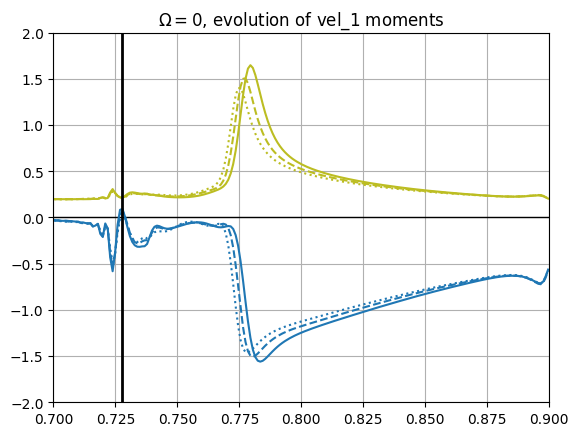

In [11]:
fig, ax = plt.subplots()
ax.set_xlim(0.7, 0.9)
ax.set_ylim(-2,2)

ax.axhline(0, color='k',linewidth=1)

# ax.plot(df['radius']/r_tot,df['nabla'])
# ax.plot(df['radius']/r_tot,df['nabla_adiab'])
# ax.plot(df['radius']/r_tot,df['nabla'] - df['nabla_adiab'])
# ax.scatter(df['radius']/r_tot,vel_1_rms)

# ax.plot(df_1['radius']/r_tot,df_1['super_adiab']/0.0005,c='tab:brown', label='super_adiab')
# ax.plot(df_1['radius']/r_tot,df_1['vel_1_std']/5E3,c='tab:cyan', label='std')
# ax.plot(df_1['radius']/r_tot,vel_1_rms/5E3,c='tab:red', label='rms')
ax.plot(df_1['radius']/r_tot,df_1['vel_1_skew']/1.5,c='tab:blue', label='skew')
ax.plot(df_1['radius']/r_tot,df_1['vel_1_kurt']/15,c='tab:olive', label='kurt')

ax.plot(df_2['radius']/r_tot,df_2['vel_1_skew']/1.5,c='tab:blue', linestyle='--', label='skew')
ax.plot(df_2['radius']/r_tot,df_2['vel_1_kurt']/15,c='tab:olive', linestyle='--', label='kurt')

ax.plot(df_3['radius']/r_tot,df_3['vel_1_skew']/1.5,c='tab:blue', linestyle=':', label='skew')
ax.plot(df_3['radius']/r_tot,df_3['vel_1_kurt']/15,c='tab:olive', linestyle=':', label='kurt')

ax.axvline(r_env_init / r_tot, color='k', label='Schw_1D',linewidth=2)

# ax.axvline(51303170466.0108 / r_tot, linestyle='--', color='r', label='first zero')
ax.grid()
# ax.legend(framealpha=1)
plt.title(f1_name + ', evolution of vel_1 moments')
plt.savefig('evo_vel_mom_wide.png')

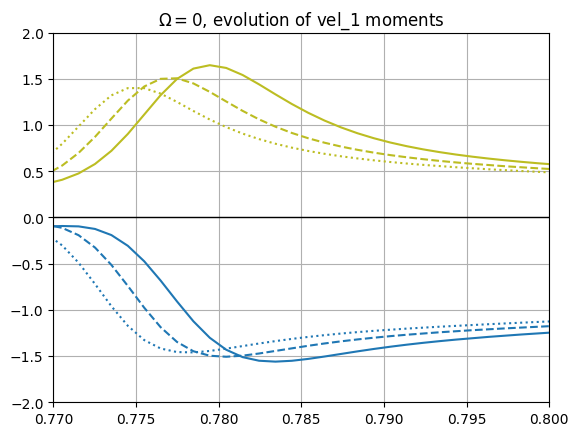

In [12]:
fig, ax = plt.subplots()
ax.set_xlim(0.77, 0.8)
ax.set_ylim(-2,2)

ax.axhline(0, color='k',linewidth=1)

# ax.plot(df['radius']/r_tot,df['nabla'])
# ax.plot(df['radius']/r_tot,df['nabla_adiab'])
# ax.plot(df['radius']/r_tot,df['nabla'] - df['nabla_adiab'])
# ax.scatter(df['radius']/r_tot,vel_1_rms)

# ax.plot(df_1['radius']/r_tot,df_1['super_adiab']/0.0005,c='tab:brown', label='super_adiab')
# ax.plot(df_1['radius']/r_tot,df_1['vel_1_std']/5E3,c='tab:cyan', label='std')
# ax.plot(df_1['radius']/r_tot,vel_1_rms/5E3,c='tab:red', label='rms')
ax.plot(df_1['radius']/r_tot,df_1['vel_1_skew']/1.5,c='tab:blue', label='skew')
ax.plot(df_1['radius']/r_tot,df_1['vel_1_kurt']/15,c='tab:olive', label='kurt')

ax.plot(df_2['radius']/r_tot,df_2['vel_1_skew']/1.5,c='tab:blue', linestyle='--', label='skew')
ax.plot(df_2['radius']/r_tot,df_2['vel_1_kurt']/15,c='tab:olive', linestyle='--', label='kurt')

ax.plot(df_3['radius']/r_tot,df_3['vel_1_skew']/1.5,c='tab:blue', linestyle=':', label='skew')
ax.plot(df_3['radius']/r_tot,df_3['vel_1_kurt']/15,c='tab:olive', linestyle=':', label='kurt')

ax.axvline(r_env_init / r_tot, color='k', label='Schw_1D',linewidth=2)

# ax.axvline(51303170466.0108 / r_tot, linestyle='--', color='r', label='first zero')
ax.grid()
# ax.legend(framealpha=1)
plt.title(f1_name + ', evolution of vel_1 moments')
plt.savefig('evo_vel_mom.png')

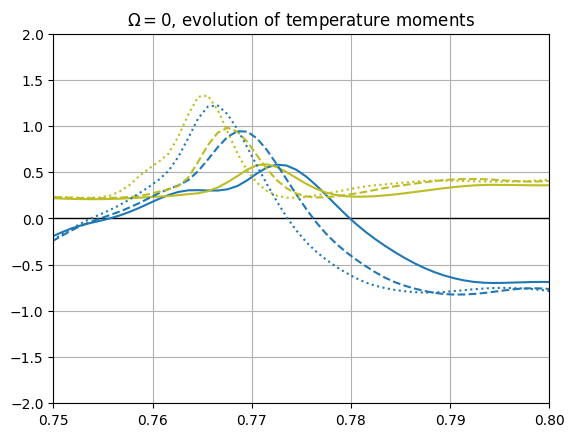

In [23]:
fig, ax = plt.subplots()
ax.set_xlim(0.75, 0.8)
ax.set_ylim(-2,2)

ax.axhline(0, color='k',linewidth=1)

# ax.plot(df['radius']/r_tot,df['nabla'])
# ax.plot(df['radius']/r_tot,df['nabla_adiab'])
# ax.plot(df['radius']/r_tot,df['nabla'] - df['nabla_adiab'])
# ax.scatter(df['radius']/r_tot,vel_1_rms)

# ax.plot(df_1['radius']/r_tot,df_1['super_adiab']/0.0005,c='tab:brown', label='super_adiab')
# ax.plot(df_1['radius']/r_tot,df_1['vel_1_std']/5E3,c='tab:cyan', label='std')
# ax.plot(df_1['radius']/r_tot,vel_1_rms/5E3,c='tab:red', label='rms')

ax.plot(df_1['radius']/r_tot,df_1['temperature_skew']/1.5,c='tab:blue', label='skew')
ax.plot(df_1['radius']/r_tot,df_1['temperature_kurt']/15,c='tab:olive', label='kurt')

ax.plot(df_2['radius']/r_tot,df_2['temperature_skew']/1.5,c='tab:blue', linestyle='--', label='skew')
ax.plot(df_2['radius']/r_tot,df_2['temperature_kurt']/15,c='tab:olive', linestyle='--', label='kurt')

ax.plot(df_3['radius']/r_tot,df_3['temperature_skew']/1.5,c='tab:blue', linestyle=':', label='skew')
ax.plot(df_3['radius']/r_tot,df_3['temperature_kurt']/15,c='tab:olive', linestyle=':', label='kurt')

ax.axvline(r_env_init / r_tot, color='k', label='Schw_1D',linewidth=2)

# ax.axvline(51303170466.0108 / r_tot, linestyle='--', color='r', label='first zero')
ax.grid()
# ax.legend(framealpha=1)
plt.title(f1_name + ', evolution of temperature moments')
plt.savefig('evo_temp_mom.png')

In [14]:
def read_file_timed(fname):
    with open(fname, "r") as f:
        f.readline()
        time = f.readline().split()[0]
    df = pd.DataFrame(np.genfromtxt(fname,skip_header=3),columns=headers)
    df['time'] = float(time)
    return df

In [15]:
all_data = pd.concat([read_file_timed(f) for f in all_files], ignore_index=True)
all_data["index"] = all_data["index"].astype(int)
all_data = all_data.set_index(["time", "index"]).sort_index()
all_data

radius       vel_rms  crossing_time_vel  \
time       index                                                  
19999820.0 1      2.834495e+10     26.836669       2.616304e+06   
           2      2.841516e+10     54.365659       1.291493e+06   
           3      2.848537e+10     63.471863       1.106205e+06   
           4      2.855558e+10     67.955728       1.033215e+06   
           5      2.862580e+10     66.538785       1.055218e+06   
...                        ...           ...                ...   
27500240.0 500    6.338118e+10  12099.574879       5.802922e+03   
           501    6.345139e+10  12251.856899       5.730796e+03   
           502    6.352161e+10  12518.987611       5.608512e+03   
           503    6.359182e+10  12983.779159       5.407739e+03   
           504    6.366203e+10  13731.819396       5.113153e+03   

                  crossing_time_hp  press_height    e_int_spec     nabla  \
time       index                                                           
19999820.0 1          3.224655e+08  5.164848e+09  1.026718e+15  0.193558   
           2          1.534306e+08  5.142397e+09  1.024071e+15  0.192556   
           3          1.286731e+08  5.146040e+09  1.021443e+15  0.192169   
           4          1.184411e+08  5.149710e+09  1.018825e+15  0.192177   
           5          1.200783e+08  5.153392e+09  1.016216e+15  0.192176   
...                            ...           ...           ...       ...   
27500240.0 500        2.690728e+05  2.543955e+09  1.402670e+14  0.394874   
           501        2.669570e+05  2.521364e+09  1.388799e+14  0.394830   
           502        2.640997e+05  2.498722e+09  1.374955e+14  0.394783   
           503        2.581910e+05  2.476017e+09  1.361143e+14  0.395025   
           504        2.432388e+05  2.446306e+09  1.347340e+14  0.394652   

                  nabla_adiab      pressure   temperature  ...  vel_1_kurt  \
time       index                                           ...               
19999820.0 1         0.396748  2.449488e+15  5.098064e+06  ...    2.941287   
           2         0.396747  2.416259e+15  5.084648e+06  ...    2.958631   
           3         0.396747  2.383504e+15  5.071328e+06  ...    3.004797   
           4         0.396746  2.351216e+15  5.058054e+06  ...    2.959369   
           5         0.396745  2.319388e+15  5.044821e+06  ...    2.984286   
...                       ...           ...           ...  ...         ...   
27500240.0 500       0.394890  2.125220e+12  6.386993e+05  ...    3.634970   
           501       0.394855  2.067109e+12  6.317461e+05  ...    3.605282   
           502       0.394818  2.010086e+12  6.248074e+05  ...    3.498659   
           503       0.394781  1.954137e+12  6.178839e+05  ...    3.298476   
           504       0.394743  1.899250e+12  6.109647e+05  ...    3.119115   

                    vel_1_rms  temperature_gradient  thermal_conductivity  \
time       index                                                            
19999820.0 1         1.088178              0.000191          2.077919e+15   
           2         0.801870              0.000190          2.075424e+15   
           3         0.759979              0.000189          2.073093e+15   
           4         0.780980              0.000189          2.070770e+15   
           5         0.796146              0.000188          2.068441e+15   
...                       ...                   ...                   ...   
27500240.0 500    4654.471000              0.000099          1.887417e+13   
           501    3989.532000              0.000099          1.822736e+13   
           502    3161.005000              0.000099          1.759796e+13   
           503    2101.923000              0.000099          1.698960e+13   
           504     754.744900              0.000099          1.639542e+13   

                  strain_dev_1_1_squared  strain_dev_2_2_squared  \
time       index                                                   
19999820.0

In [16]:
arr = all_data["vel_1_kurt"].groupby(level="time").idxmax().values
vel_1_kurt_max = np.array([all_data.loc[i, 'radius'] for i in arr])
arr = all_data["vel_1_skew"].groupby(level="time").idxmin().values
vel_1_skew_min = np.array([all_data.loc[i, 'radius'] for i in arr])

Text(0.5, 1.0, '$\\Omega=0$, evolution of kurt & skew peaks')

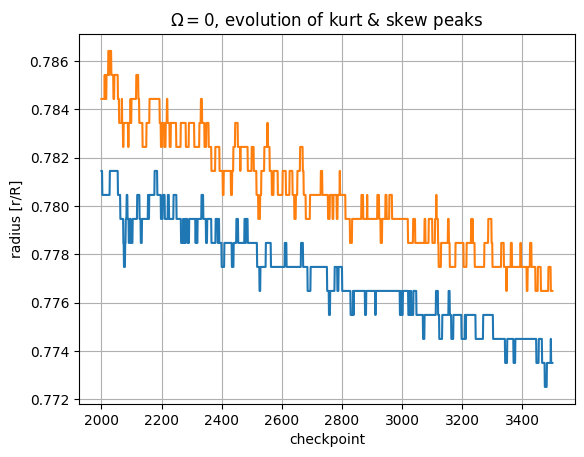

In [17]:
plt.plot(np.arange(len(vel_1_kurt_max)) + 2000, vel_1_kurt_max/r_tot)
plt.plot(np.arange(len(vel_1_skew_min)) + 2000, vel_1_skew_min/r_tot)
plt.grid()
plt.ylabel('radius [r/R]')
plt.xlabel('checkpoint')
plt.title(f1_name + ', evolution of kurt & skew peaks')

In [18]:
kurt_val = all_data["vel_1_kurt"].groupby(level="time").max().values
skew_val = all_data["vel_1_skew"].groupby(level="time").min().values

In [19]:
time = all_data["vel_1_skew"].groupby(level="time").min().index

Text(0.5, 1.0, '$\\Omega=0$, evolution of vel_1 moments')

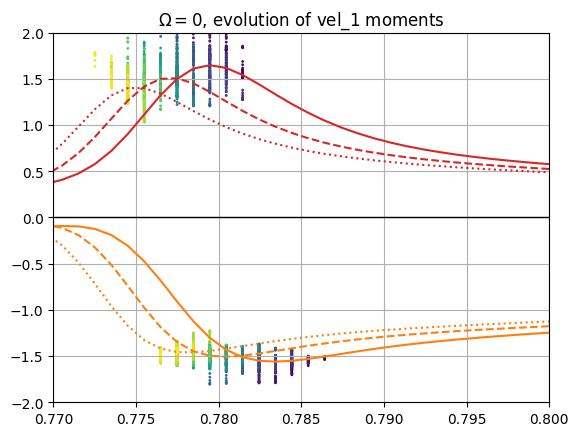

In [20]:
fig, ax = plt.subplots()
ax.set_xlim(0.77, 0.8)
ax.set_ylim(-2,2)

ax.axhline(0, color='k',linewidth=1)

# ax.plot(df['radius']/r_tot,df['nabla'])
# ax.plot(df['radius']/r_tot,df['nabla_adiab'])
# ax.plot(df['radius']/r_tot,df['nabla'] - df['nabla_adiab'])
# ax.scatter(df['radius']/r_tot,vel_1_rms)

# ax.plot(df_1['radius']/r_tot,df_1['super_adiab']/0.0005,c='tab:brown', label='super_adiab')
# ax.plot(df_1['radius']/r_tot,df_1['vel_1_std']/5E3,c='tab:cyan', label='std')
# ax.plot(df_1['radius']/r_tot,vel_1_rms/5E3,c='tab:red', label='rms')
ax.plot(df_1['radius']/r_tot,df_1['vel_1_skew']/1.5,c='tab:orange', label='skew')
ax.plot(df_1['radius']/r_tot,df_1['vel_1_kurt']/15,c='tab:red', label='kurt')

ax.plot(df_2['radius']/r_tot,df_2['vel_1_skew']/1.5,c='tab:orange', linestyle='--', label='skew')
ax.plot(df_2['radius']/r_tot,df_2['vel_1_kurt']/15,c='tab:red', linestyle='--', label='kurt')

ax.plot(df_3['radius']/r_tot,df_3['vel_1_skew']/1.5,c='tab:orange', linestyle=':', label='skew')
ax.plot(df_3['radius']/r_tot,df_3['vel_1_kurt']/15,c='tab:red', linestyle=':', label='kurt')

ax.axvline(r_env_init / r_tot, color='k', label='Schw_1D',linewidth=2)

ax.scatter(vel_1_kurt_max/r_tot, kurt_val/15,s=1, c=time,cmap='viridis')
ax.scatter(vel_1_skew_min/r_tot, skew_val/1.5,s=1, c=time,cmap='viridis')
# ax.axvline(51303170466.0108 / r_tot, linestyle='--', color='r', label='first zero')
ax.grid()
# ax.legend(framealpha=1)
plt.title(f1_name + ', evolution of vel_1 moments')
# plt.savefig('velocity_moments.png')

In [21]:
np.mean([vel_1_skew_min[0], vel_1_kurt_max[0]])

np.float64(55412016190.5)